# Missing Data Reconstruction from Pretrained Embeddings

For this example we're going to create a simpler finetuning set up to train a model with one channel corrupted. As we have a pretrained model the decoder is going to attempt to reconstruct our lost data.

# Missing Data Reconstruction from Pretrained Embeddings

For this example we're going to create a simpler finetuning set up to train a model with one channel corrupted. As we have a pretrained model the decoder is going to attempt to reconstruct our lost data.

Load config and datamodule as before. 

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import omegaconf
import pandas as pd
from torchmetrics import MeanAbsoluteError, MeanSquaredError, R2Score
import sunpy.visualization.colormaps as sunpycm

from sdofmv2.core import SDOMLDataModule, MAE
from sdofmv2.utils import ALL_WAVELENGTHS
from sdofmv2.tasks.missing_data import MissingDataModel

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = omegaconf.OmegaConf.load("../../../configs/downstream/finetune_missing_config_sdofmv2.yml")

data_module = SDOMLDataModule(
    hmi_path=None,
    aia_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.aia,
        )
        if cfg.data.sdoml.sub_directory.aia
        else None
    ),
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    pin_memory=cfg.data.pin_memory,
    persistent_workers=cfg.data.persistent_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

2026-03-09 01:32:16.663 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/131A_2019-01-0100:00:00-2019-12-3123:59:59.990000_norm-log.json
2026-03-09 01:32:16.664 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/1600A_2019-01-0100:00:00-2019-12-3123:59:59.990000_norm-log.json
2026-03-09 01:32:16.664 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/1700A_2019-01-0100:00:00-2019-12-3123:59:59.990000_norm-log.json
2026-03-09 01:32:16.664 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/171A_2019-01-0100:00:00-2019-12-3123:59:59.990000_norm-log.json
2026-03-09 01:32:16.665 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/193A_2019-01-0100:00:00-2019-12-3123:59:59.990000_norm-log.json
202

[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_AIA_FULL_12min_2019-01-0100:00:00-2019-12-3123:59:59.990000.csv.
[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.


### Create a Missing Data Model

Here we create a `forward_corrupt_data_override` function to replace our typical training forward pass to rudely set an entire input channel to `0`.

In [3]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [4]:
# visualize samples
timestamps = [
    "2019-12-25 00:24:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x = data_module.test_ds[img_indices[0]][0].unsqueeze(0)
corrupted_img = x.clone()

# define missing channels
corrupted_img[:, 5, :, :, :] = 0

Load in a pretrained model as before.

In [5]:
backbone = MAE.load_from_checkpoint(
    checkpoint_path=os.path.join(
        cfg.experiment.backbone.ckpt_dir, cfg.experiment.backbone.weight_name
    ),
    map_location="cpu",
    weights_only=False
)

zero_shot = MAE.load_from_checkpoint(
    checkpoint_path=os.path.join(
        cfg.experiment.backbone.ckpt_dir, cfg.experiment.backbone.weight_name
    ),
    map_location="cpu",
    weights_only=False
)

Create our model.

In [6]:
backbone_params = {}
backbone_params["optimizer_dict"] = cfg.model.optimizer
backbone_params["scheduler_dict"] = cfg.model.scheduler


model = MissingDataModel(
    **backbone_params,
    backbone=backbone,
    hyperparam_ignore=["backbone"],
)

Begin training!

In [7]:
from lightning.pytorch import Trainer
os.environ["PJRT_DEVICE"] = "GPU"

if not os.path.exists("final_model_v2.ckpt"):
    trainer = Trainer(max_epochs=2, precision=32)
    trainer.fit(model=model, datamodule=data_module)
    trainer.save_checkpoint("final_model_v2.ckpt", weights_only=False)

else:
    print("Check point is found!")
    model = MissingDataModel.load_from_checkpoint(
        checkpoint_path="final_model_v2.ckpt",
        map_location="cpu",
        weights_only=False,
        backbone=backbone
    )

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' |

2026-03-09 01:32:19.895 | DEBUG    | sdofmv2.core.basemodule:configure_optimizers:33 - Initial/Peak LR: 0.0003
2026-03-09 01:32:19.896 | DEBUG    | sdofmv2.core.basemodule:configure_optimizers:34 - Weight decay: 0.05
Loading `train_dataloader` to estimate number of stepping batches.
2026-03-09 01:32:20.103 | DEBUG    | sdofmv2.core.basemodule:configure_optimizers:82 - Scheduler initialized with TOTAL_STEPS = 14084


┏━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone │ MAE  │  114 M │ train │     0 │
└───┴──────────┴──────┴────────┴───────┴───────┘

Trainable params: 28.6 M                                                                                           
Non-trainable params: 86.4 M                                                                                       
Total params: 114 M                                                                                                
Total estimated model params size (MB): 459                                                                        
Modules in train mode: 186                                                                                         
Modules in eval mode: 265                                                                                          
Total FLOPs: 0

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 265
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=2` reached.


In [ ]:
def compute_metrics(preds, targets):
    """
    Computes MSE, RMSE, MAE, and R2 for (Batch, Channel, Height, Width) data.
    """
    rmse_metric = MeanSquaredError(squared=False) 
    mse_metric = MeanSquaredError(squared=True)
    mae_metric = MeanAbsoluteError()
    r2_metric = R2Score()

    rmse = rmse_metric(preds, targets)
    mse = mse_metric(preds, targets)
    mae = mae_metric(preds, targets)
    r2 = r2_metric(preds.flatten(), targets.flatten())

    return mse, rmse, mae, r2

In [13]:
loss, x_hat, mask = model(corrupted_img)
x_hat_zero_shot, mask_zero_shot = zero_shot(corrupted_img)

mse, rmse, mae, r2 = compute_metrics(x*zero_shot.limb_mask, x_hat*zero_shot.limb_mask)
print(f"MSE: {mse.item():.4f}")
print(f"RMSE: {rmse.item():.4f}")
print(f"MAE: {mae.item():.4f}")
print(f"R2: {r2.item():.4f}")
print("------------------------------------------")

mse_zero, rmse_zero, mae_zero, r2_zero = compute_metrics(x*zero_shot.limb_mask, x_hat_zero_shot*zero_shot.limb_mask)
print(f"MSE_zero_shot: {mse_zero.item():.4f}")
print(f"RMSE_zero_shot: {rmse_zero.item():.4f}")
print(f"MAE_zero_shot: {mae_zero.item():.4f}")
print(f"R2_zero_shot: {r2_zero.item():.4f}")

MSE: 0.0002
RMSE: 0.0158
MAE: 0.0081
R2: 0.9949
------------------------------------------
MSE_zero_shot: 0.0019
RMSE_zero_shot: 0.0435
MAE_zero_shot: 0.0224
R2_zero_shot: 0.9540


In [14]:
results_list = []
ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]

print("Computing metrics...")

for i_ch, ch_index in enumerate(sort_ids):
    channel_label = ch_info[ch_index]
    
    mse, rmse, mae, r2 = compute_metrics(
        x[0, ch_index, 0, :, :] * zero_shot.limb_mask, 
        x_hat[0, ch_index, 0, :, :] * zero_shot.limb_mask
    )
    
    mse_zero, rmse_zero, mae_zero, r2_zero = compute_metrics(
        x[0, ch_index, 0, :, :] * zero_shot.limb_mask, 
        x_hat_zero_shot[0, ch_index, 0, :, :] * zero_shot.limb_mask
    )

    results_list.append({
        "Channel": f"{channel_label}Å",
        "MAE": mae.item(),
        "MAE (zero-shot)": mae_zero.item(),
        "MSE": mse.item(),
        "MSE (zero-shot)": mse_zero.item(),
        "RMSE": rmse.item(),
        "RMSE (zero-shot)": rmse_zero.item(),
        "R2": r2.item(),
        "R2 (zero-shot)": r2_zero.item(),
    })

df = pd.DataFrame(results_list)

mean_values = df.mean(numeric_only=True)
mean_row = mean_values.to_dict()
mean_row["Channel"] = "Mean"

df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
df_transposed = df.set_index("Channel").T
df_transposed = df_transposed.round(4)

Computing metrics...


In [15]:
df_transposed

Channel,94Å,131Å,171Å,193Å,211Å,304Å,335Å,1600Å,1700Å,Mean
MAE,0.0040,0.0083,0.0112,0.0074,0.0094,0.0111,0.0070,0.0073,0.0073,0.0081
MAE (zero-shot),0.0049,0.0202,0.0623,0.0370,0.0181,0.0172,0.0084,0.0057,0.0279,0.0224
MSE,0.0001,0.0002,0.0004,0.0002,0.0004,0.0004,0.0002,0.0002,0.0002,0.0002
MSE (zero-shot),0.0001,0.0011,0.0083,0.0034,0.0012,0.0009,0.0003,0.0001,0.0017,0.0019
RMSE,0.0076,0.0157,0.0204,0.0149,0.0190,0.0202,0.0130,0.0135,0.0136,0.0153
RMSE (zero-shot),0.0097,0.0331,0.0910,0.0580,0.0345,0.0306,0.0161,0.0109,0.0407,0.0361
R2,0.9223,0.9693,0.9943,0.9949,0.9878,0.9868,0.9524,0.9962,0.9985,0.9781
R2 (zero-shot),0.8527,0.7792,0.8143,0.8879,0.9641,0.9648,0.9351,0.9976,0.9845,0.9089


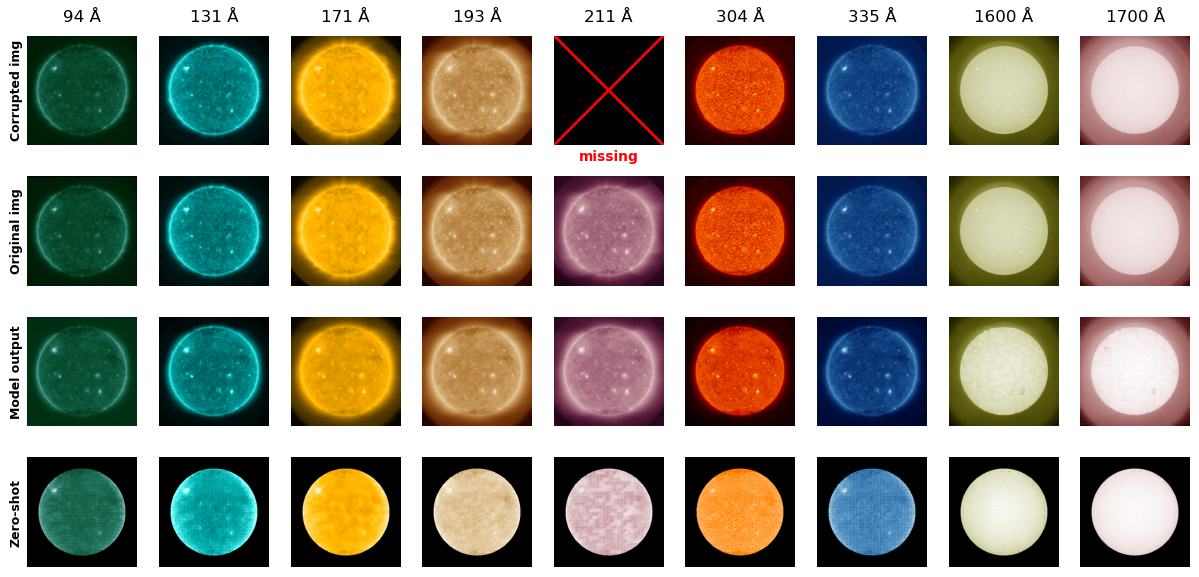

In [16]:
x_hat_np = x_hat.detach().numpy()
x_hat_zero_shot_np = x_hat_zero_shot.detach().numpy()
limb_mask = zero_shot.limb_mask.detach().numpy()

ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]
fig, axes = plt.subplots(nrows=4, ncols=9, figsize=(15, 7))

# Turn off axes and spines for all subplots initially
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i_ch, ch_index in enumerate(sort_ids):
    channel_label = ch_info[ch_index]

    if channel_label == "211":
        # Special handling for the 211 Å channel
        axes[0, i_ch].set_facecolor('black') # Set background to black
        axes[0, i_ch].set_aspect('equal')
        
        # Draw a red cross
        # We need to define the limits to draw the cross from corner to corner
        axes[0, i_ch].set_xlim(0, 1)
        axes[0, i_ch].set_ylim(0, 1)
        axes[0, i_ch].plot([0, 1], [0, 1], color='red', linewidth=2)
        axes[0, i_ch].plot([0, 1], [1, 0], color='red', linewidth=2)
        
        
        # Add the text
        axes[0, i_ch].text(0.5, -0.1, "missing", 
                color='red', 
                ha='center', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

    axes[0, i_ch].imshow(corrupted_img[0, ch_index, 0, :, :], cmap=cms[ch_index])
    axes[1, i_ch].imshow(x[0, ch_index, 0, :, :], cmap=cms[ch_index])
    axes[2, i_ch].imshow(x_hat_np[0, ch_index, 0, :, :], cmap=cms[ch_index])
    axes[3, i_ch].imshow(x_hat_zero_shot_np[0, ch_index, 0, :, :] * limb_mask, cmap=cms[ch_index])

    
    # Set the title for all channels
    axes[0, i_ch].set_title(f"{channel_label} Å", fontsize=12, pad=10)


axes[0][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Corrupted img", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[0][0].transAxes # Ensures coordinates are relative to the subplot
    )

axes[1][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Original img", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[1][0].transAxes # Ensures coordinates are relative to the subplot
    )

axes[2][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Model output", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[2][0].transAxes # Ensures coordinates are relative to the subplot
    )

axes[3][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Zero-shot", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[3][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.savefig("DS_missing_data_img_result.pdf", dpi=300, bbox_inches="tight")